In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import model_definition as m
import utils as u

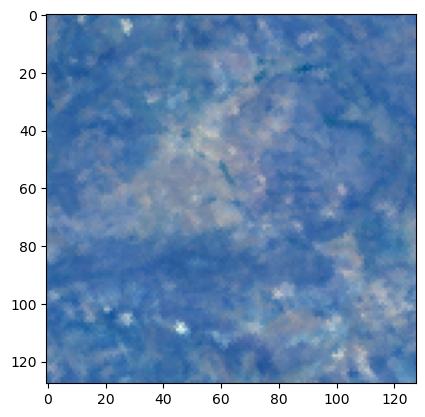

In [2]:
h5_file = h5py.File('/new_emit_dataset_vol/just_hypercubes/20230403T111207/chip_0.h5', 'r')
h5_array = np.array(h5_file['hypercube'])
u.visualize_hypercube(h5_array)

In [3]:
# Training Setup:
num_epochs = 100
report_every = 10
batch_size = 16
learning_rate = 0.001

# Model Setup:
device = torch.device("cuda")
model = m.SimpleHyperspectralMAEEncoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

fake_dataset = []
for i in range(128):
    fake_dataset.append(h5_array)
dataloader = torch.utils.data.DataLoader(fake_dataset, batch_size=batch_size, shuffle=True)


In [4]:
# Overfit single chip:
model.train()
for epoch in range(num_epochs):
    for batch in dataloader:
        batch = batch.to(device)
        loss = model(batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    if (epoch+1) % report_every == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.item()}")

Epoch 10, Loss: 9.030903816223145
Epoch 20, Loss: 9.021424293518066
Epoch 30, Loss: 9.022807121276855
Epoch 40, Loss: 9.01679515838623
Epoch 50, Loss: 9.017072677612305
Epoch 60, Loss: 9.015172958374023
Epoch 70, Loss: 9.012066841125488
Epoch 80, Loss: 9.009933471679688
Epoch 90, Loss: 9.009098052978516
Epoch 100, Loss: 9.003392219543457


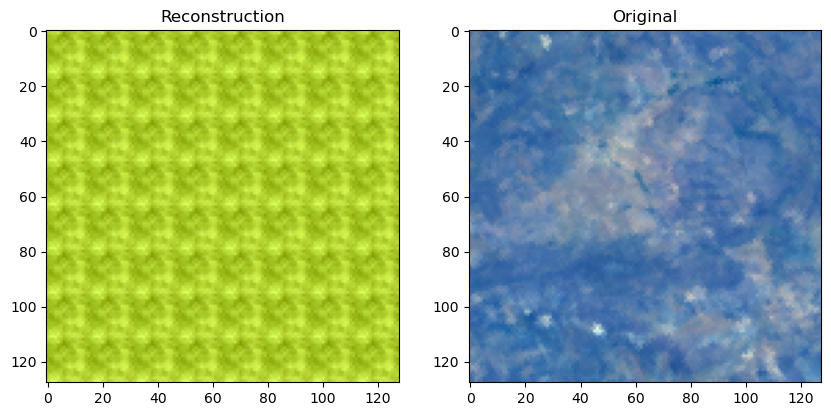

In [5]:
model.eval()
pred_hwc, _ = model.reconstruct(batch)
u.visualize_reconstruction(pred_hwc[0].cpu().numpy(), h5_array)